In [6]:
from sklearn.datasets import make_regression
import numpy as np

In [7]:
x, y = make_regression(
    n_samples=4,
    n_features=1,
    n_informative=1,
    n_targets=1,
    noise=80,
    random_state=1
)

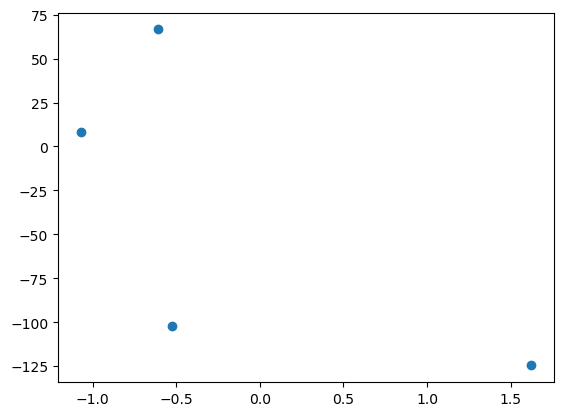

In [8]:
import matplotlib.pyplot as plt

plt.scatter(x, y)

In [9]:
x.shape

(4, 1)

In [10]:
y.shape

(4,)

In [11]:
x

array([[-1.07296862],
       [-0.61175641],
       [ 1.62434536],
       [-0.52817175]])

In [12]:
# First we are going to apply OLS

from sklearn.linear_model import LinearRegression

In [286]:
reg = LinearRegression()
reg.fit(x, y)

LinearRegression()

In [14]:
# Slope
reg.coef_

array([-50.61708585])

In [15]:
# Y Intercept
reg.intercept_

np.float64(-45.44115263199092)

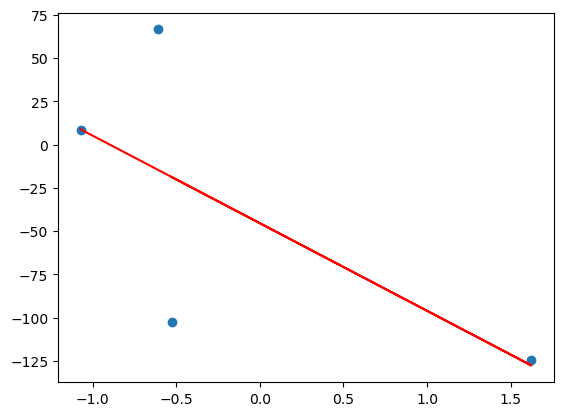

In [16]:
plt.scatter(x, y)
plt.plot(x, reg.predict(x), color='red')

# Learning GD by using formulas

In [17]:
# Lets apply Gradient Descent assuming slope is constant m = -50.617
# and lets assume the starting value for intercept is b = 0
# Formula for bnew = bold - learningRate * slope
# Formula for ypred = slope * x + intercept


y_pred = ((-50.617 * x) + (0)).reshape(4)

In [18]:
y_pred

array([ 54.31045275,  30.96527439, -82.21948927,  26.73446958])

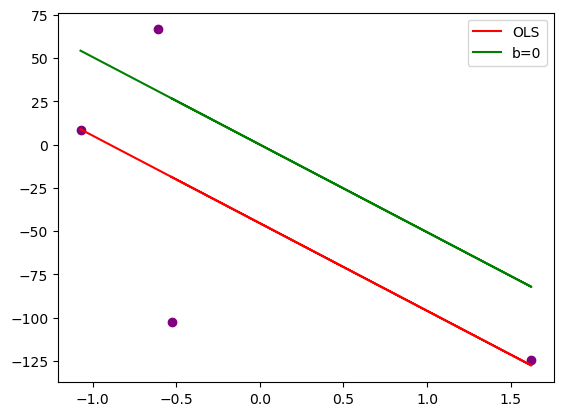

In [19]:
plt.scatter(x, y, color='purple')
plt.plot(x, reg.predict(x), color='red', label='OLS')
plt.plot(x, y_pred, color='green', label='b=0')
plt.legend()
plt.show()

In [20]:
m = -50.617
b = 0

In [21]:
# Loss Function wrt slope = -2 sum(yi - mxi -b)

loss_slope = -2 * np.sum(y - m * x.ravel() - b) 
loss_slope

np.float64(363.52912000737757)

In [22]:
# bnew = bold - learningRate * slope
# Assume learning_rate = 0.1

lr = 0.1
step_size = lr * loss_slope
step_size

np.float64(36.35291200073776)

In [23]:
# Calculate new intercept

b = b - step_size
b

np.float64(-36.35291200073776)

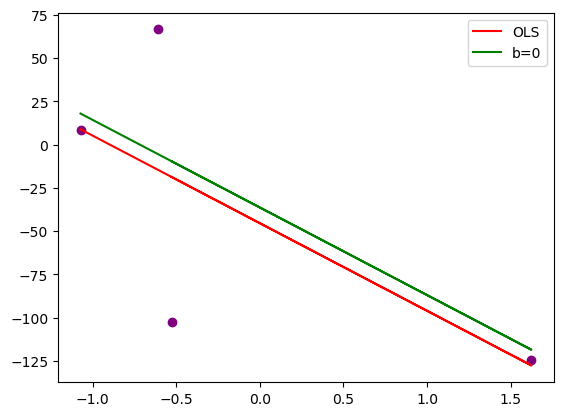

In [24]:
# Calculating y_pred

y_pred = ((-50.617 * x) + (b)).reshape(4)

plt.scatter(x, y, color='purple')
plt.plot(x, reg.predict(x), color='red', label='OLS')
plt.plot(x, y_pred, color='green', label='b=0')
plt.legend()
plt.show()

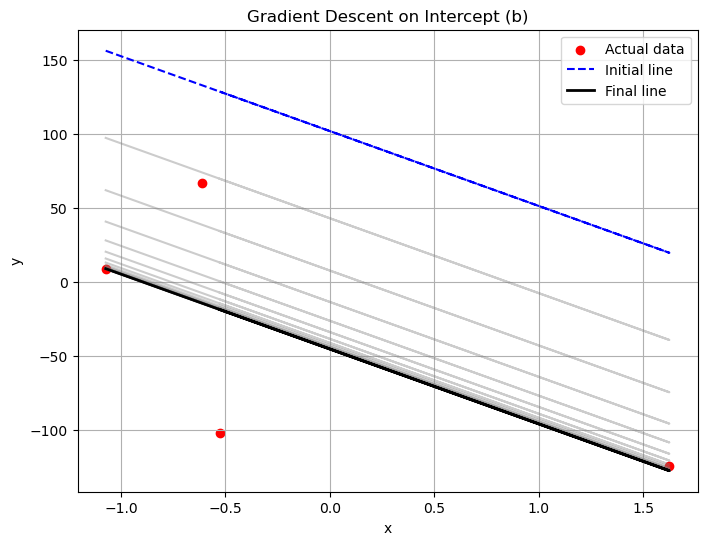

In [25]:
b = 200
m = -50.617
lr = 0.05
epochs = 30

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='red', label='Actual data')

for i in range(epochs):
    grad_b = -2 * np.sum(y - m * x.ravel() - b)
    b = b - lr * grad_b

    y_pred = m * x.ravel() + b

    if i == 0:
        plt.plot(x, y_pred, color='blue', linestyle='--', label='Initial line')
    elif i == epochs - 1:
        plt.plot(x, y_pred, color='black', linewidth=2, label='Final line')
    else:
        plt.plot(x, y_pred, color='gray', alpha=0.4)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Descent on Intercept (b)')
plt.legend()
plt.grid(True)
plt.show()

# Custom Gradient Descent when m already known

In [53]:
class CustomGD:

    def __init__(self, learning_rate=0.01, epochs=20):
        self.m = -50.617
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs
        self.history = []   # stores (m, b) per epoch

    def fit(self, x, y):
        x_flat = x.ravel()

        for _ in range(self.epochs):
            y_pred = self.m * x_flat + self.b

            grad_m = -2 * np.sum(x_flat * (y - y_pred))
            grad_b = -2 * np.sum(y - y_pred)

            self.m -= self.lr * grad_m
            self.b -= self.lr * grad_b

            self.history.append((self.m, self.b))


In [54]:
def plot_gd_learning(x, y, history):
    x_flat = x.ravel()
    idx = np.argsort(x_flat)
    x_sorted = x_flat[idx]
    y_sorted = y[idx]

    plt.figure(figsize=(8, 6))
    plt.scatter(x_sorted, y_sorted, color='red', label='Data')

    for i, (m, b) in enumerate(history):
        y_pred = m * x_sorted + b

        if i == 0:
            plt.plot(x_sorted, y_pred, '--', linewidth=2,
                     label='Initial line')
        elif i == len(history) - 1:
            plt.plot(x_sorted, y_pred, linewidth=3,
                     label='Final line')
        else:
            plt.plot(x_sorted, y_pred, color='gray', alpha=0.3)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Gradient Descent Learning Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.show()


In [91]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

In [113]:
x, y = make_regression(
    n_samples=20,
    n_features=20,
    noise=80,
    random_state=1
)

In [130]:
reg.fit(x, y)

print(f"Slope: {reg.coef_}")
print(f"Intercept: {reg.intercept_}")

Slope: [ 62.18662796  23.85828803 -11.23333498 126.49051785  16.92756362
  -9.73231004 -36.8765578  -43.20034524   9.44407987  16.48245808
 -81.96230445 -62.38056115  24.48519246 201.20305602 238.77490869
  76.26057718  13.72020438 108.64600531  -2.07659608  36.67406978]
Intercept: 9.382319064857917


In [72]:
gd = CustomGD(learning_rate=0.001, epochs=1000)

In [73]:
gd.fit(x, y)

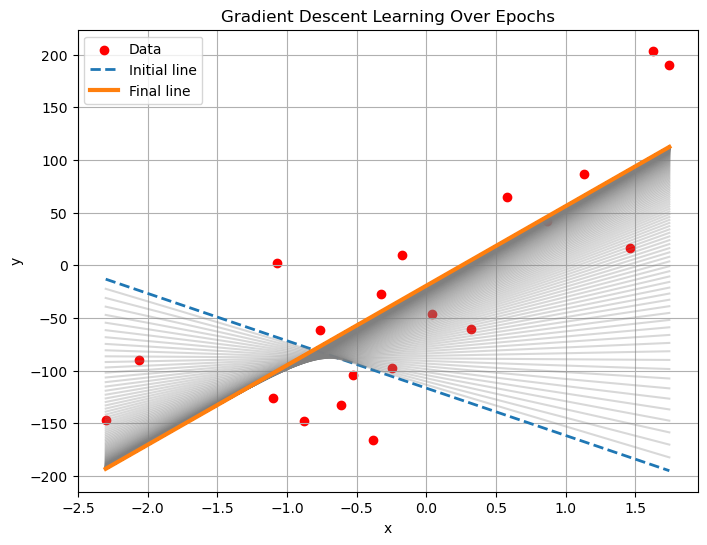

In [74]:
plot_gd_learning(x, y, gd.history)

In [75]:
gd.m

np.float64(75.52822846077761)

In [76]:
gd.b

np.float64(-19.400095129815856)

# Custom Gradient Descent for n columns

In [287]:
class CustomGradientDescent:

    def __init__(self, learning_rate=0.01, epochs=10000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.intercept_ = 0.0
        self.coef_ = np.zeros(n_features)

        for i in range(self.epochs):
            y_pred = X @ self.coef_ + self.intercept_
            error = y_pred - y

            gradient_b0 = 2 * np.mean(error)
            gradient_coefs = (2 / n_samples) * (X.T @ error)

            self.intercept_ -= self.learning_rate * gradient_b0
            self.coef_ -= self.learning_rate * gradient_coefs

        return self  

    def predict(self, X):
        return X @ self.coef_ + self.intercept_

    def get_params(self, deep=True):
        return {"learning_rate": self.learning_rate, "epochs": self.epochs}

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self


In [288]:
custom_reg = CustomGradientDescent(learning_rate=0.01, epochs=10000)

In [289]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [290]:
x, y = load_diabetes(return_X_y=True)

In [291]:
print(x.shape)
print(y.shape)

(442, 10)
(442,)


In [292]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [275]:
lr = LinearRegression()

In [276]:
lr.fit(x_train, y_train)

LinearRegression()

In [277]:
print(f"Coefs: {np.sort(lr.coef_)}")
print(f"Intercept: {lr.intercept_}")

Coefs: [-895.5520019  -205.45432163   -9.15865318   52.42112238  126.73139688
  153.89310954  340.61999905  516.69374454  561.22067904  861.12700152]
Intercept: 151.88331005254167


In [278]:
y_pred = lr.predict(x_test)

In [279]:
r2_score(y_test, y_pred)

0.4399338661568969

In [280]:
x_train.shape

(353, 10)

In [295]:
custom_reg = CustomGradientDescent(learning_rate=0.1, epochs=10000)

In [296]:
custom_reg.fit(x_train, y_train)

In [301]:
custom_reg.coef_

array([  -3.57390179, -203.281111  ,  529.13568835,  339.58177888,
        -60.27452171, -128.38068642, -189.68232707,   86.38212364,
        512.73182958,   67.08316195])

In [297]:
y_pred_custom = custom_reg.predict(x_test)

In [298]:
r2_score(y_test, y_pred_custom)

0.44734180065190465

In [299]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr,
    x,          # feature matrix
    y,          # target
    cv=5,       # 5-fold cross validation
    scoring='r2'
)

print("Cross-val scores:", scores)
print("Mean CV score:", scores.mean())

Cross-val scores: [0.42955615 0.52259939 0.48268054 0.42649776 0.55024834]
Mean CV score: 0.4823164359086422


In [300]:
scores = cross_val_score(
    custom_reg,
    x,
    y,
    cv=5,
    scoring='r2'
)

print("CV scores:", scores)
print("Mean CV score:", scores.mean())


CV scores: [0.4202806  0.52071476 0.49393687 0.42819099 0.54133013]
Mean CV score: 0.48089066990055096
